import pandas as pd
import seaborn as sns # for data visualization
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import randint as sp_randint
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_csv("SpotifyFeatures.csv")
df.head()

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390


In [4]:
# Check for missing values in the DataFrame
missing_values = pd.isnull(df).sum()

# Print the number of missing values
print(f'Number of missing values: {missing_values}')

Number of missing values: genre               0
artist_name         0
track_name          1
track_id            0
popularity          0
acousticness        0
danceability        0
duration_ms         0
energy              0
instrumentalness    0
key                 0
liveness            0
loudness            0
mode                0
speechiness         0
tempo               0
time_signature      0
valence             0
dtype: int64


There are no missing values so further operation is needed.

In [5]:
df.dtypes

genre                object
artist_name          object
track_name           object
track_id             object
popularity            int64
acousticness        float64
danceability        float64
duration_ms           int64
energy              float64
instrumentalness    float64
key                  object
liveness            float64
loudness            float64
mode                 object
speechiness         float64
tempo               float64
time_signature       object
valence             float64
dtype: object

The features 'artist_name','track_name','track_id' are not relevant for the genre classification task, hence we will exclude them from our analysis. However, we will investigate the 'time_signature' feature, as it is an object type feature and its distribution within the dataset may provide insights into the genre classification.

Text(0.5, 1.0, 'Time_signature Distribution')

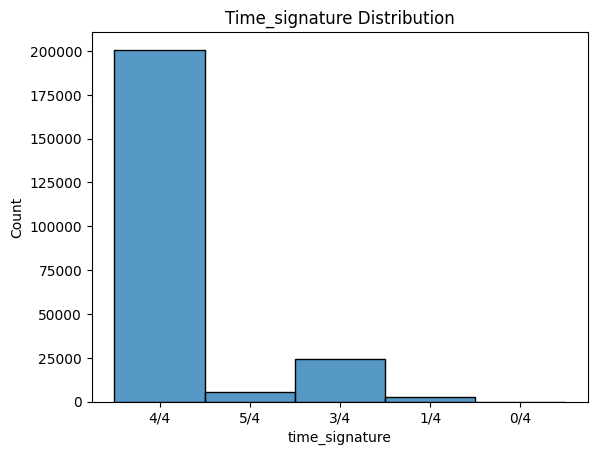

In [6]:
sns.histplot(df['time_signature']).set_title('Time_signature Distribution')

As the time signatures of 1/4 and 0/4 are not prevalent in our dataset, we will remove songs with these time signatures in order to achieve a more balanced dataset.

In [7]:
df = df[~df['time_signature'].isin(['0/4', '1/4'])]

Text(0.5, 1.0, 'Time Signature Distribution')

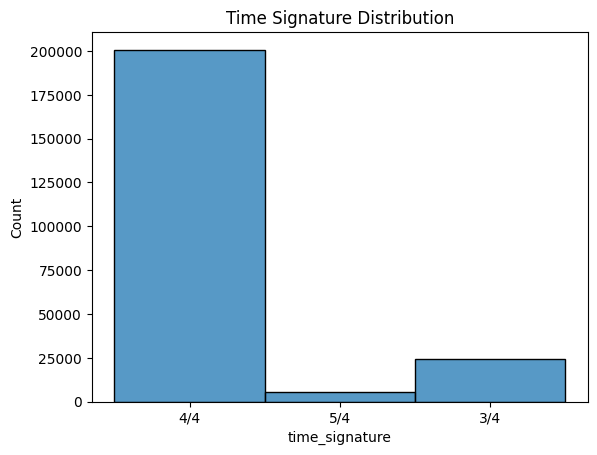

In [8]:
sns.histplot(df['time_signature']).set_title('Time Signature Distribution')

We will do the genre distribution to make sure that we have an even number of songs in each genre

Text(0.5, 1.0, 'Genre Distribution')

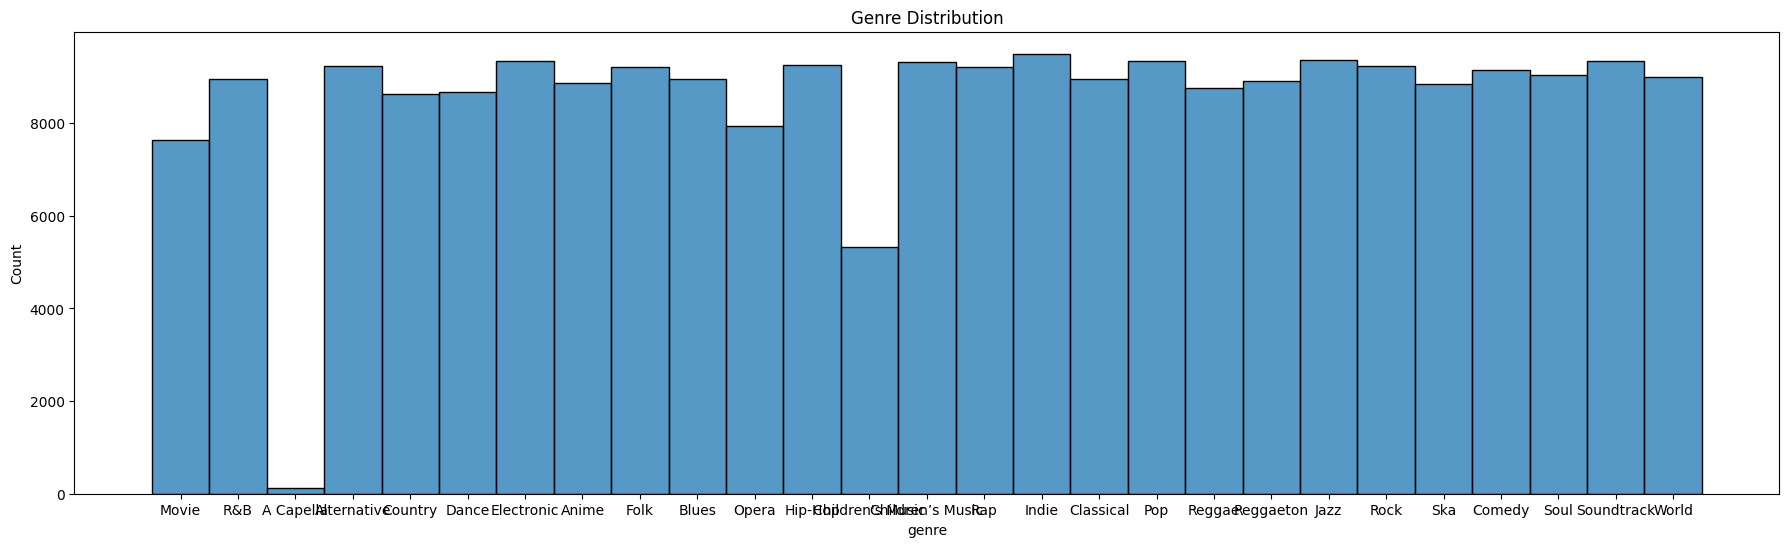

In [9]:
plt.figure(figsize=(22, 6))
sns.histplot(df['genre']).set_title('Genre Distribution')

In [10]:
df['genre'].value_counts().sort_index()

genre
A Capella            114
Alternative         9231
Anime               8858
Blues               8956
Children's Music    5337
Children’s Music    9321
Classical           8953
Comedy              9139
Country             8640
Dance               8678
Electronic          9338
Folk                9221
Hip-Hop             9259
Indie               9499
Jazz                9362
Movie               7629
Opera               7943
Pop                 9352
R&B                 8943
Rap                 9203
Reggae              8753
Reggaeton           8913
Rock                9233
Ska                 8846
Soul                9041
Soundtrack          9347
World               9000
Name: count, dtype: int64

Upon further examination, we have noticed that the 'A Capella' genre contains only 114 tracks and that the 'Children's Music' genre occurs twice in the dataset with slightly different naming conventions ('Children’s Music' and "Children's Music"), we will remove these genres from our dataset in order to have a cleaner and more balanced set of data.

In [11]:
df = df[~df.genre.isin(['A Capella', 'Children’s Music', "Children's Music"])]

In [12]:
df['genre'].value_counts().sort_index()

genre
Alternative    9231
Anime          8858
Blues          8956
Classical      8953
Comedy         9139
Country        8640
Dance          8678
Electronic     9338
Folk           9221
Hip-Hop        9259
Indie          9499
Jazz           9362
Movie          7629
Opera          7943
Pop            9352
R&B            8943
Rap            9203
Reggae         8753
Reggaeton      8913
Rock           9233
Ska            8846
Soul           9041
Soundtrack     9347
World          9000
Name: count, dtype: int64

Text(0.5, 1.0, 'Genre Distribution')

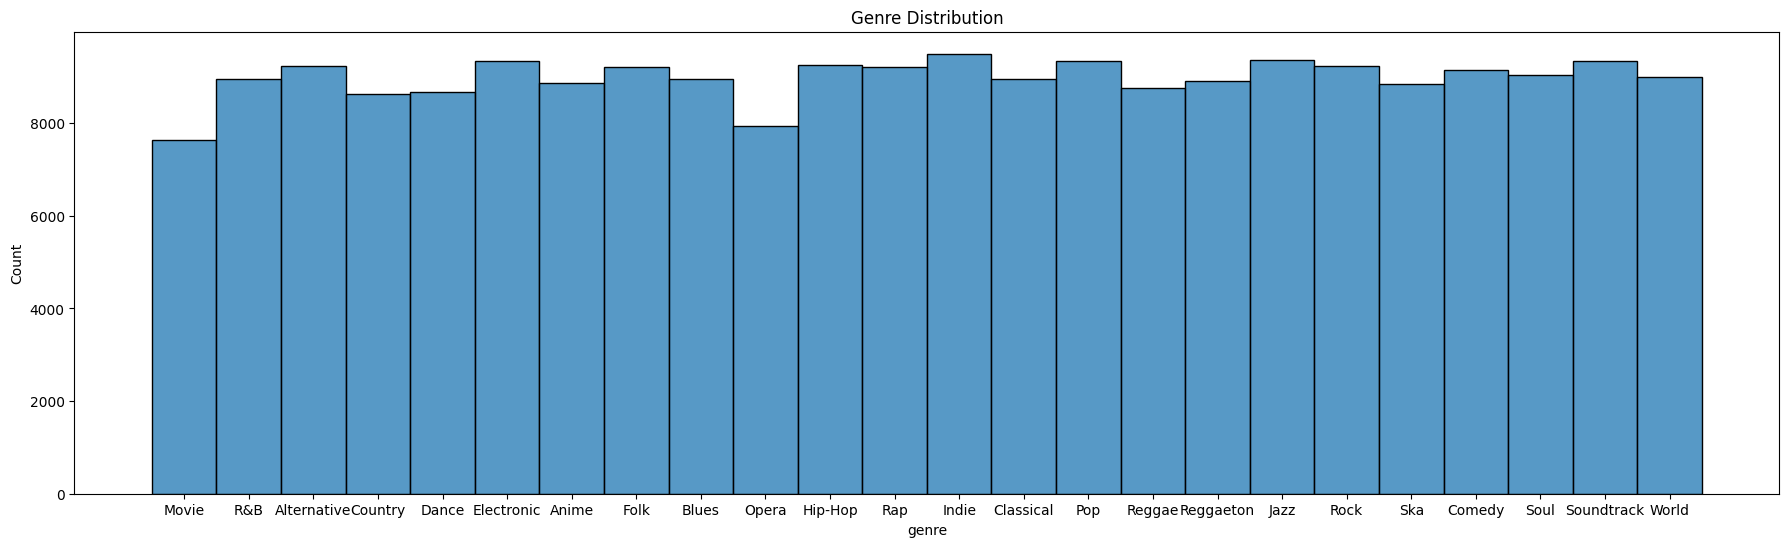

In [13]:
plt.figure(figsize=(22, 6))
sns.histplot(df['genre']).set_title('Genre Distribution')

Our next step is to identify and remove any duplicate songs in the dataset. By doing so, we can ensure that the dataset is clean and that our model is not affected by any duplicate songs. 

In [14]:
# Check for duplicates in the DataFrame
duplicated_all = df[df.duplicated(subset= 'track_id' , keep=False)]
duplicated = df[df.duplicated(subset='track_id', keep='first')]

# Get the number of unique duplicates and total duplicates
num_unique_duplicates = duplicated.shape[0]
num_total_duplicates = duplicated_all.shape[0]

# Get the total number of rows in the DataFrame
num_total_rows = df.shape[0]

# Calculate the proportion of duplicates in the DataFrame
duplicates_proportion = round(num_total_duplicates / num_total_rows * 100, 2)

# Print the results
print(f'Number of unique duplicates: {num_unique_duplicates}')
print(f'Number of total duplicates: {num_total_duplicates}')
print(f'Total number of rows: {num_total_rows}')
print(f'Proportion of duplicates: {duplicates_proportion}%')

Number of unique duplicates: 46964
Number of total duplicates: 79213
Total number of rows: 215337
Proportion of duplicates: 36.79%


In [15]:
df_new = df.drop_duplicates(subset = 'track_id', keep=False)
df_new = df_new.reset_index(drop=True)

X=df_new.drop(['track_id'],axis=1)
X['genre'].value_counts().sort_index()

genre
Alternative    3811
Anime          8493
Blues          7206
Classical      7778
Comedy         9131
Country        6514
Dance          2769
Electronic     8154
Folk           4317
Hip-Hop        1933
Indie          2149
Jazz           7126
Movie          7312
Opera          7567
Pop            1321
R&B            2838
Rap             983
Reggae         7677
Reggaeton      8513
Rock           2014
Ska            7994
Soul           4392
Soundtrack     8186
World          7946
Name: count, dtype: int64

After removing all duplicate tracks, we observed that the distribution of genres in our dataset has changed significantly. In order to maintain a balance of genres in our dataset, we will need to remove some genres completely. This will ensure that our model is not biased towards any particular genre and that the results are accurate and generalizable.

In [16]:
X = df_new.drop(df_new[df_new['genre'].isin(['World','Reggaeton','Pop','Alternative','Dance','Hip-Hop','R&B','Rock','Rap','Indie'])].index)
X.reset_index(drop=True, inplace=True)
X['genre'].value_counts().sort_index()


genre
Anime         8493
Blues         7206
Classical     7778
Comedy        9131
Country       6514
Electronic    8154
Folk          4317
Jazz          7126
Movie         7312
Opera         7567
Reggae        7677
Ska           7994
Soul          4392
Soundtrack    8186
Name: count, dtype: int64

In the remaining genres in our dataset, there are certain genres that may musically overlap. In order to evaluate the impact of this on our model's accuracy, we will need to analyze the relationship between these overlapping genres and their effect on the classification results. This can be done by comparing the performance of the model with and without these overlapping genres, and observing any changes in the accuracy of the model.

In [17]:
# The genres Blues, Classical, Opera, and Soundtrack are less likely to overlap musically
X.drop(X[X['genre'].isin(['Soundtrack','Blues','Folk','Opera','Reggae','Soul','Ska','Comedy','Movie','Anime'])].index, inplace=True)
X['genre'].value_counts().sort_index()

genre
Classical     7778
Country       6514
Electronic    8154
Jazz          7126
Name: count, dtype: int64

In order to use the data in our machine learning model, we will need to perform the necessary encoding on the object-type data.

In [18]:
# Convert the mode, genre, time_signature, key features to strings
X['genre'] = X['genre'].astype(str)
X['mode'] = X['mode'].astype(str)
X['time_signature'] = X['time_signature'].astype(str)
X['key'] = X['key'].astype(str)

# Create a label encoder
le = LabelEncoder()

# Fit the label encoder to the mode feature and transform the mode feature using the label encoder
le.fit(X['mode'])
X['mode'] = le.transform(X['mode'])

# Fit the label encoder to the time_signature feature and transform the time_signature feature using the label encoder
le.fit(X['time_signature'])
X['time_signature'] = le.transform(X['time_signature'])

# Fit the label encoder to the 'key' feature and transform the feature using the label encoder
le.fit(X['key'])
X['key'] = le.transform(X['key'])

# Fit the label encoder to the 'genre' feature and transform the feature using the label encoder
le.fit(X['genre'])
X['genre'] = le.transform(X['genre'])

In [19]:
X.head()

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
395,1,Cam,My Mistake,5ICoYTFfmUKguBHpINKkGL,45,0.00821,0.551,200013,0.704,0.000002,11,0.2450,-5.426,0,0.0444,97.075,1,0.541
396,1,Kevin Fowler,That Girl,0rk6JE7ODyGWWquK4y7t1u,42,0.02720,0.375,208187,0.859,0.000000,10,0.2670,-3.243,0,0.0569,74.059,1,0.597
397,1,Chris Cagle,Anywhere But Here,2JxSaSRavL82FCTCPzVmEf,42,0.57100,0.640,243000,0.478,0.000000,2,0.0902,-6.960,0,0.0330,136.717,1,0.315
398,1,Cassadee Pope,I Wish I Could Break Your Heart,4wrjIq1lskP8tZuQBEdcux,44,0.13000,0.435,220413,0.846,0.000000,11,0.0920,-4.169,0,0.0496,199.895,1,0.631
399,1,Mark Chesnutt,Too Cold At Home,5oqxLuRvQFjV4k0orrXs5d,41,0.19900,0.638,219573,0.412,0.000009,5,0.3190,-12.901,0,0.0242,92.832,1,0.509


Text(0.5, 1.0, 'Key usage for every genre')

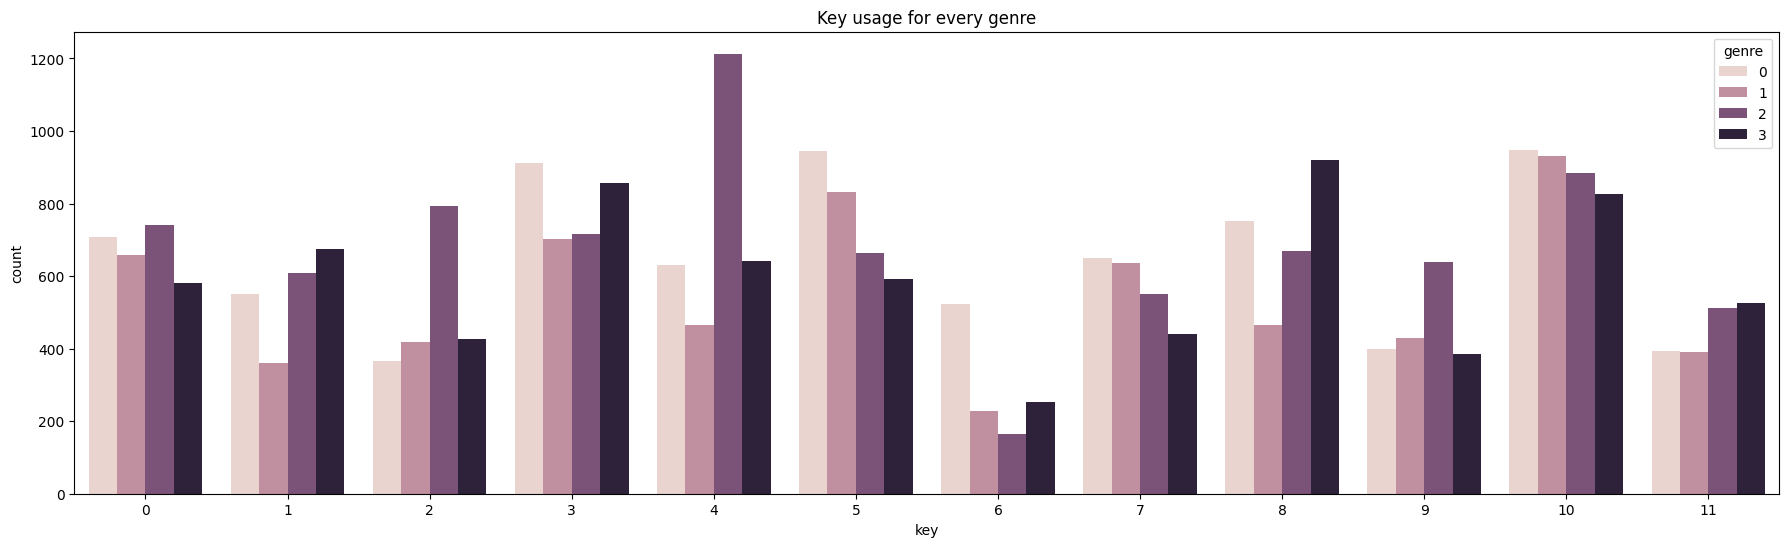

In [20]:
plt.figure(figsize=(22, 6))
sns.countplot(x = 'key', hue = 'genre', data = X)
plt.title('Key usage for every genre')

Text(0.5, 1.0, 'Key usage for every genre')

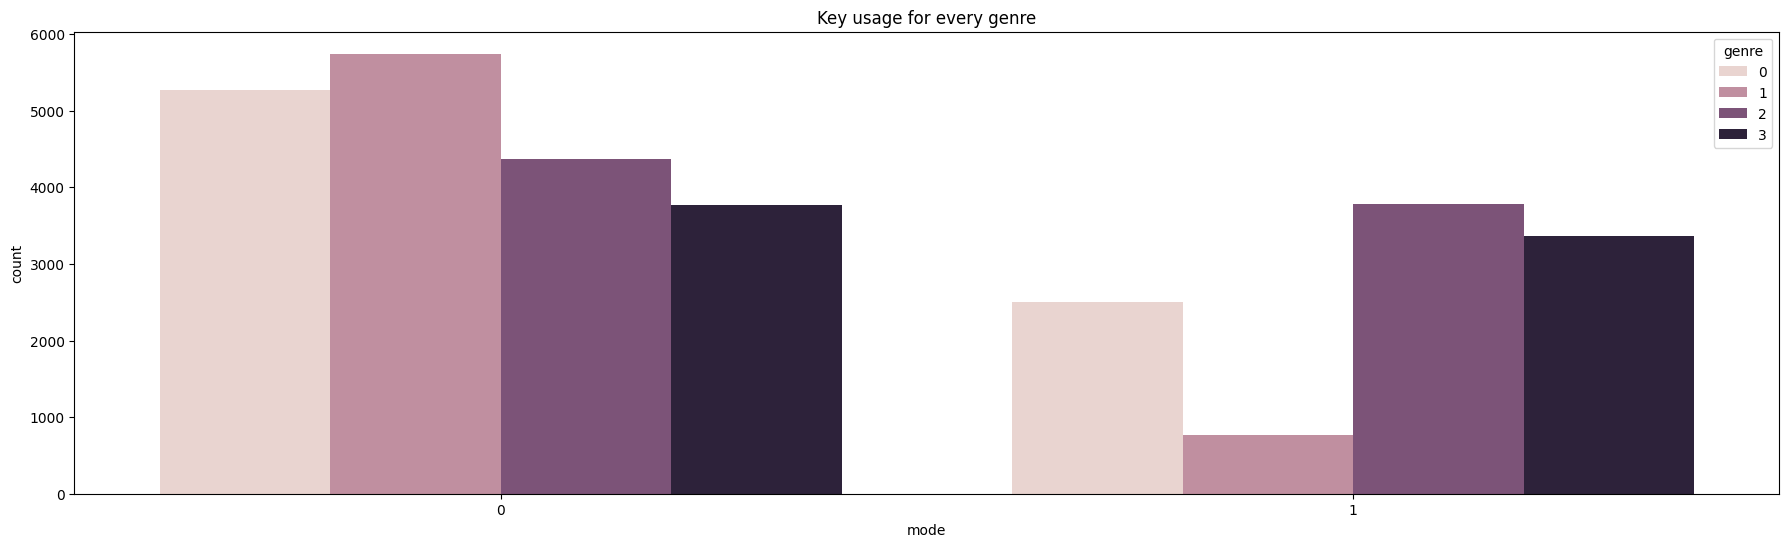

In [21]:
plt.figure(figsize=(22, 6))
sns.countplot(x = 'mode', hue = 'genre', data = X)
plt.title('Key usage for every genre')

Text(0.5, 1.0, 'Key usage for every genre')

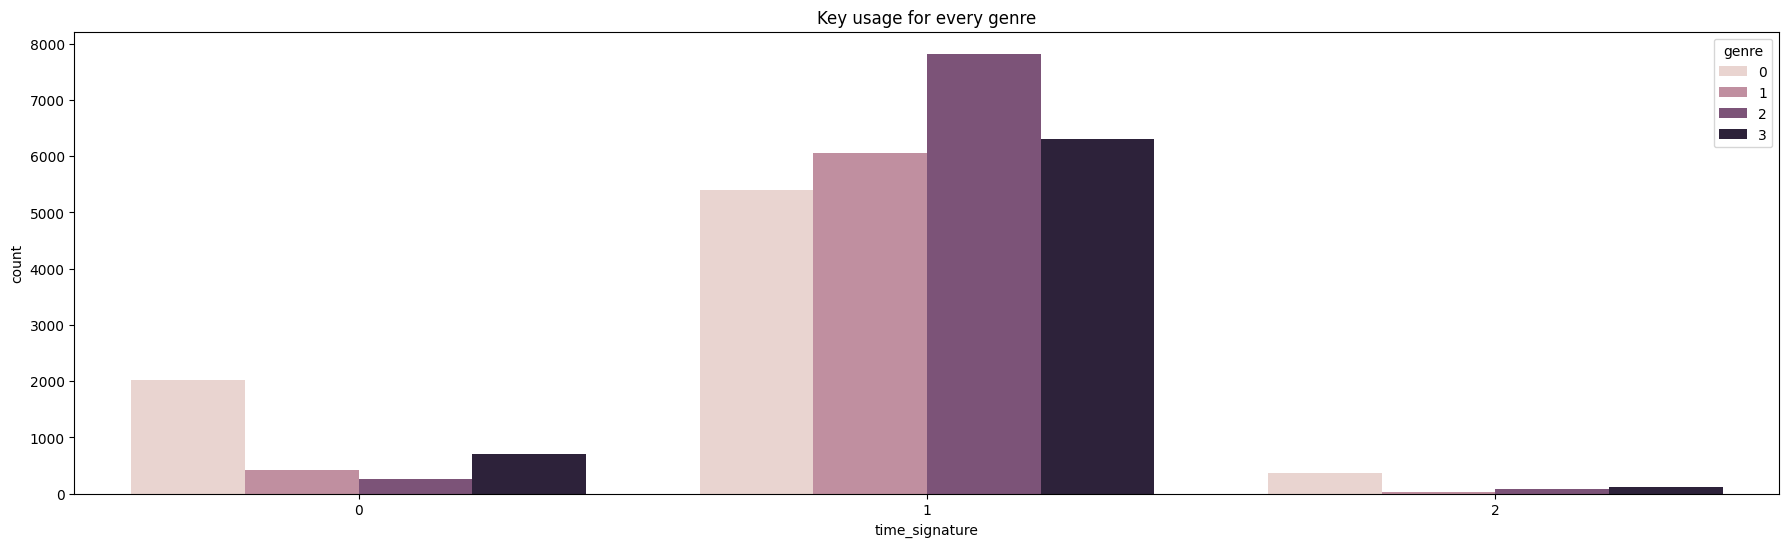

In [22]:
plt.figure(figsize=(22, 6))
sns.countplot(x = 'time_signature', hue = 'genre', data = X)
plt.title('Key usage for every genre')

Text(0.5, 1.0, 'Key usage for every genre')

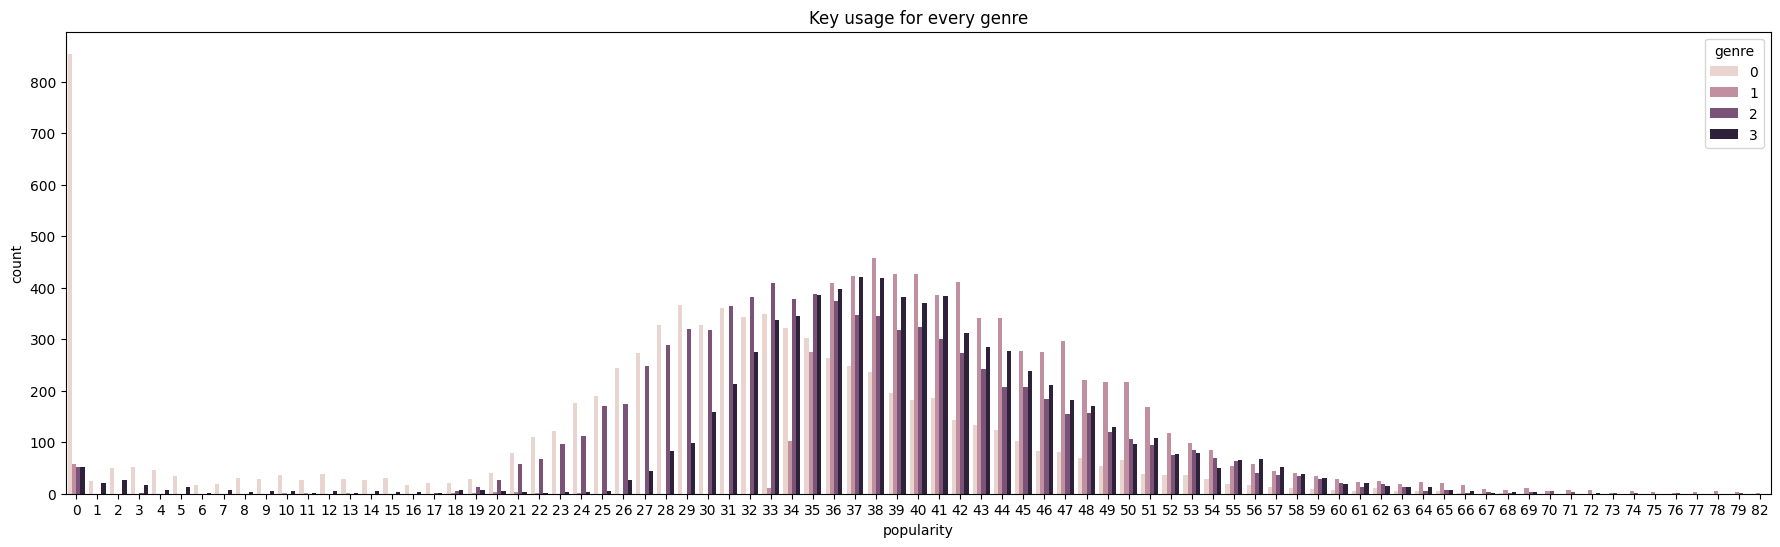

In [23]:
plt.figure(figsize=(22, 6))
sns.countplot(x = 'popularity', hue = 'genre', data = X)
plt.title('Key usage for every genre')

Feature importance
We have decided to retain all of the audio features provided by the Spotify API in our analysis, as they have proven to be highly indicative of a song's genre. However, we have determined that the "mode" and "key" features may not be as useful in our analysis, as any song can be in any mode and start with any key. Additionally, the "popularity" feature may not be as useful in determining a song's genre, as it may only be indicative of a genre's conventional popularity. Therefore, we will remove the "mode", "key" and "popularity" features from our analysis.
We will also drop any genres that overlap musically

In [24]:
# Removing 'mode', 'key', 'popularity'
# Defining X and y
y = X['genre']
X = X.drop(['track_name','artist_name','track_id','popularity','genre','key','mode'],axis = 1)

In [25]:
X.head()

,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,time_signature,valence
395,0.00821,0.551,200013,0.704,0.000002,0.2450,-5.426,0.0444,97.075,1,0.541
396,0.02720,0.375,208187,0.859,0.000000,0.2670,-3.243,0.0569,74.059,1,0.597
397,0.57100,0.640,243000,0.478,0.000000,0.0902,-6.960,0.0330,136.717,1,0.315
398,0.13000,0.435,220413,0.846,0.000000,0.0920,-4.169,0.0496,199.895,1,0.631
399,0.19900,0.638,219573,0.412,0.000009,0.3190,-12.901,0.0242,92.832,1,0.509


Training and evaluation

In [26]:
# Set the seed for reproducibility
np.random.seed(42)

# Convert dataframe to numpy array
X_final = np.array(X)
y_final = np.array(y)

Support Vector Machine Models 

In [27]:
# Shuffle data
X_final, y_final = shuffle(X_final, y_final)

# Split data into training and testing set
X_train, X_test, y_train, y_test = train_test_split( X_final , y_final , test_size=0.2 , random_state=42 ) 

In [28]:
# Scaling our data 
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [29]:
%%time
# Defining our model
clf_svm = SVC()

# Training our train data without hyperparameter tuning
clf_svm.fit(X_train,y_train)
predict_svm = clf_svm.predict(X_test)

# Measuring accuracy
accouracy_svm = accuracy_score(y_test, predict_svm)
print('The accuracy of SVM model without hyperparameter tuning is: %f' % accouracy_svm)
print(classification_report(y_test, predict_svm))

The accuracy of SVM model without hyperparameter tuning is: 0.800338
              precision    recall  f1-score   support

           0       0.91      0.88      0.89      1599
           1       0.75      0.84      0.80      1244
           2       0.79      0.79      0.79      1654
           3       0.73      0.69      0.71      1418

    accuracy                           0.80      5915
   macro avg       0.80      0.80      0.80      5915
weighted avg       0.80      0.80      0.80      5915

CPU times: user 6.97 s, sys: 800 ms, total: 7.77 s
Wall time: 7.79 s


In [30]:
%%time
# Finding best hyperparameters
param_svm_={'C':[1,10,100],
       'kernel':('linear','poly','rbf'),
       'degree' : [1,2,4,6]
       }

# Define model 
clf_svm_best = SVC()
model_svm_best = GridSearchCV(clf_svm_best,param_svm_)

# Fitting best parameters given by GridSearchCV function 
model_svm_best.fit(X_train,y_train)
print("The best hyperparameters are :",model_svm_best.best_params_ )

# Assessing performance with a test that wasnt part of the training with the best hyperparameters
predict_svm_best = model_svm_best.predict(X_test)
accouracy_of_best_svm_ = accuracy_score(y_test, predict_svm_best)
print('Accuracy with the best hyperparameters: %f' % accouracy_of_best_svm_)
print(classification_report(y_test, predict_svm_best))

The best hyperparameters are : {'C': 10, 'degree': 1, 'kernel': 'rbf'}
Accuracy with the best hyperparameters: 0.804396
              precision    recall  f1-score   support

           0       0.90      0.89      0.89      1599
           1       0.77      0.84      0.80      1244
           2       0.80      0.79      0.79      1654
           3       0.73      0.70      0.71      1418

    accuracy                           0.80      5915
   macro avg       0.80      0.80      0.80      5915
weighted avg       0.80      0.80      0.80      5915

CPU times: user 40min 10s, sys: 6.04 s, total: 40min 16s
Wall time: 40min 16s


Random Forest Classifier Model

In [31]:
# Shuffle data
X_final, y_final = shuffle(X_final, y_final)

# Split data into training and testing set
X_train, X_test, y_train, y_test = train_test_split( X_final , y_final , test_size=0.2 , random_state=42 ) 

In [32]:
# Scaling our data 
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [33]:
%%time
# Define Model 
clf_rf = RandomForestClassifier()

# Training our train data without hyperparameter tuning
clf_rf.fit(X_train, y_train)
predict_rf = clf_rf.predict(X_test)

# Measuring accuracy
accouracy_rf = accuracy_score(y_test, predict_rf)
print('The accuracy of Random Forests model without hyperparameter tuning is: %f'% accouracy_rf)
print(classification_report(y_test, predict_rf))

The accuracy of Random Forests model without hyperparameter tuning is: 0.821809
              precision    recall  f1-score   support

           0       0.91      0.90      0.91      1587
           1       0.83      0.84      0.84      1299
           2       0.80      0.82      0.81      1638
           3       0.73      0.72      0.73      1391

    accuracy                           0.82      5915
   macro avg       0.82      0.82      0.82      5915
weighted avg       0.82      0.82      0.82      5915

CPU times: user 4.68 s, sys: 7.98 ms, total: 4.69 s
Wall time: 4.69 s


In [ ]:
# Finding best hyperparameters for kernel and C value
param_rf_ = {'n_estimators': [5,20,50,70,100],
            'max_depth': [5, 10, 15, 20,50,70,90,110,None],
            'min_samples_leaf': [1,2,4,6,8,10],
            'min_samples_split': [1,4,8,12,15],
            'criterion': ['gini', 'entropy']}

# Define model
clf_rf_best = RandomForestClassifier()
model_rf_best =GridSearchCV(clf_rf_best,param_rf_)

# Fitting best parameters given by GridSearchCV function 
# to a shuffled train set
model_rf_best.fit(X_train,y_train)

print("The best hyperparameters are :",model_rf_best.best_params_ )

# Assessing performance with a test that wasnt part of the training with the best hyperparameters
predict_rf_best = model_rf_best.predict(X_test)
accouracy_of_best_rf_ = accuracy_score(y_test, predict_rf_best)
print(' Accuracy with the best hyperparameters: %f' % accouracy_of_best_rf_)
print(classification_report(y_test, predict_rf_best))

Multi-layer Perceptron classifier

In [ ]:
# Shuffle data
X_final, y_final = shuffle(X_final, y_final)

# Split data into training and testing set
X_train, X_test, y_train, y_test = train_test_split( X_final , y_final , test_size=0.2 , random_state=42 ) 

In [ ]:
-=

In [ ]:
%%time
# Let's try with a Neural Network
# Define Model 
clf_mlp = MLPClassifier()

# Training our train data without hyperparameter tuning
clf_mlp.fit(X_train, y_train)
predict_mlp = clf_mlp.predict(X_test)

# Measuring accuracy
accouracy_mlp = accuracy_score(y_test, predict_mlp)
print('The accuracy of MLP model without hyperparameter tuning is %f'% accouracy_mlp)
print(classification_report(y_test, predict_mlp))

The accuracy of MLP model without hyperparameter tuning is 0.802536
              precision    recall  f1-score   support

           0       0.89      0.88      0.89      1609
           1       0.79      0.85      0.82      1272
           2       0.79      0.80      0.79      1647
           3       0.72      0.67      0.69      1387

    accuracy                           0.80      5915
   macro avg       0.80      0.80      0.80      5915
weighted avg       0.80      0.80      0.80      5915

CPU times: total: 1min 45s
Wall time: 17.6 s


C:\ProgramData\Anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
%%time 
# Define Model 
mlp_gs = MLPClassifier()
parameter_space = {
    'hidden_layer_sizes': [(100, 100), (100, 100, 100), (100, 100, 100, 100)],
    'activation': ['tanh', 'relu'],
    'solver': ['sgd','adam'],
    'alpha': [0.0001, 0.001, 0.01, 0.1],
    'max_iter': [500]
}


# Fitting best parameters given by GridSearchCV function 
clf = GridSearchCV(mlp_gs, parameter_space, n_jobs=-1, cv=5, scoring='accuracy', verbose=10, error_score="raise")
best_clf = clf.fit(X_train, y_train) 

# best score achieved during the GridSearchCV
print('GridSearch CV best score : {:.4f}\n\n'.format(clf.best_score_))

# print parameters that give the best results
print('Parameters that give the best results :','\n\n', (clf.best_params_))

# Assessing performance with a test that wasnt part of the training with the best hyperparameters
predict_mlp_best = best_clf.predict(X_test)
accouracy_of_best_mlp_ = accuracy_score(y_test, predict_mlp_best)
print(' Accuracy with the best hyperparameters: %f' % accouracy_of_best_mlp_)
print(classification_report(y_test, predict_mlp_best))

Fitting 5 folds for each of 48 candidates, totalling 240 fits
GridSearch CV best score : 0.8083


Parameters that give the best results : 

 {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (100, 100), 'max_iter': 500, 'solver': 'adam'}
 Accuracy with the best hyperparameters: 0.811158
              precision    recall  f1-score   support

           0       0.90      0.89      0.89      1609
           1       0.79      0.88      0.83      1272
           2       0.78      0.83      0.80      1647
           3       0.76      0.64      0.70      1387

    accuracy                           0.81      5915
   macro avg       0.81      0.81      0.81      5915
weighted avg       0.81      0.81      0.81      5915

CPU times: total: 10min 55s
Wall time: 1h 54min 34s


In [ ]:
%%time

# Finding best hyperparameters for kernel and C value
param_rf_ = {'n_estimators': [5,20,50,70,100],
            'max_depth': [5, 10, 15, 20,50,70,90,110,None],
            'min_samples_leaf': [1,2,4,6,8,10],
            'min_samples_split': [1,4,8,12,15],
            'criterion': ['gini', 'entropy']}

# Define model
clf_rf_best = RandomForestClassifier()
model_rf_best =GridSearchCV(clf_rf_best,param_rf_)

# Fitting best parameters given by GridSearchCV function 
# to a shuffled train set
model_rf_best.fit(X_train,y_train)

print("The best hyperparameters are :",model_rf_best.best_params_ )

# Assessing performance with a test that wasnt part of the training with the best hyperparameters
predict_rf_best = model_rf_best.predict(X_test)
accouracy_of_best_rf_ = accuracy_score(y_test, predict_rf_best)
print(' Accuracy with the best hyperparameters: %f' % accouracy_of_best_rf_)
print(classification_report(y_test, predict_rf_best))